In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../wavelet/')
import wavelet_funcs as wf

path.append('../signals/')
import signals as sg

path.append('../../')
import superlet as st


In [2]:
from ssqueezepy import ssq_cwt

## Cosine with a phase shift (no noise)

In [51]:
fs = 100
t,s = sg.cosine(10, 2, fs)

## Phase shift at t=4 s
t_shift = 4
ndrop = 30
s_ = s[t>t_shift][ndrop:]
s = np.concatenate((s[t<t_shift], s_))
t = np.arange(s.size)*np.diff(t)[0]

In [52]:
suplet = st.SuperletTransform(inputSize=s.size, 
                     samplingRate=fs, 
                     frequencyRange=(0.5,4),
                     frequencyBins=200,
                     baseCycles=5,
                     superletOrders=(1,5)
                    )

suplet.coefs = suplet.transform(s)

In [53]:
Tx, Wx, ssq_freqs, _, = ssq_cwt(s, wavelet='morlet', fs=fs, padtype='symmetric')

Wx = Wx[(ssq_freqs>0.5)&(ssq_freqs<4), :]
Tx = Tx[(ssq_freqs>0.5)&(ssq_freqs<4), :]
ssq_freqs = ssq_freqs[(ssq_freqs>0.5)&(ssq_freqs<4)]

Text(0.5, 1.0, '|SSQ CWT|^2')

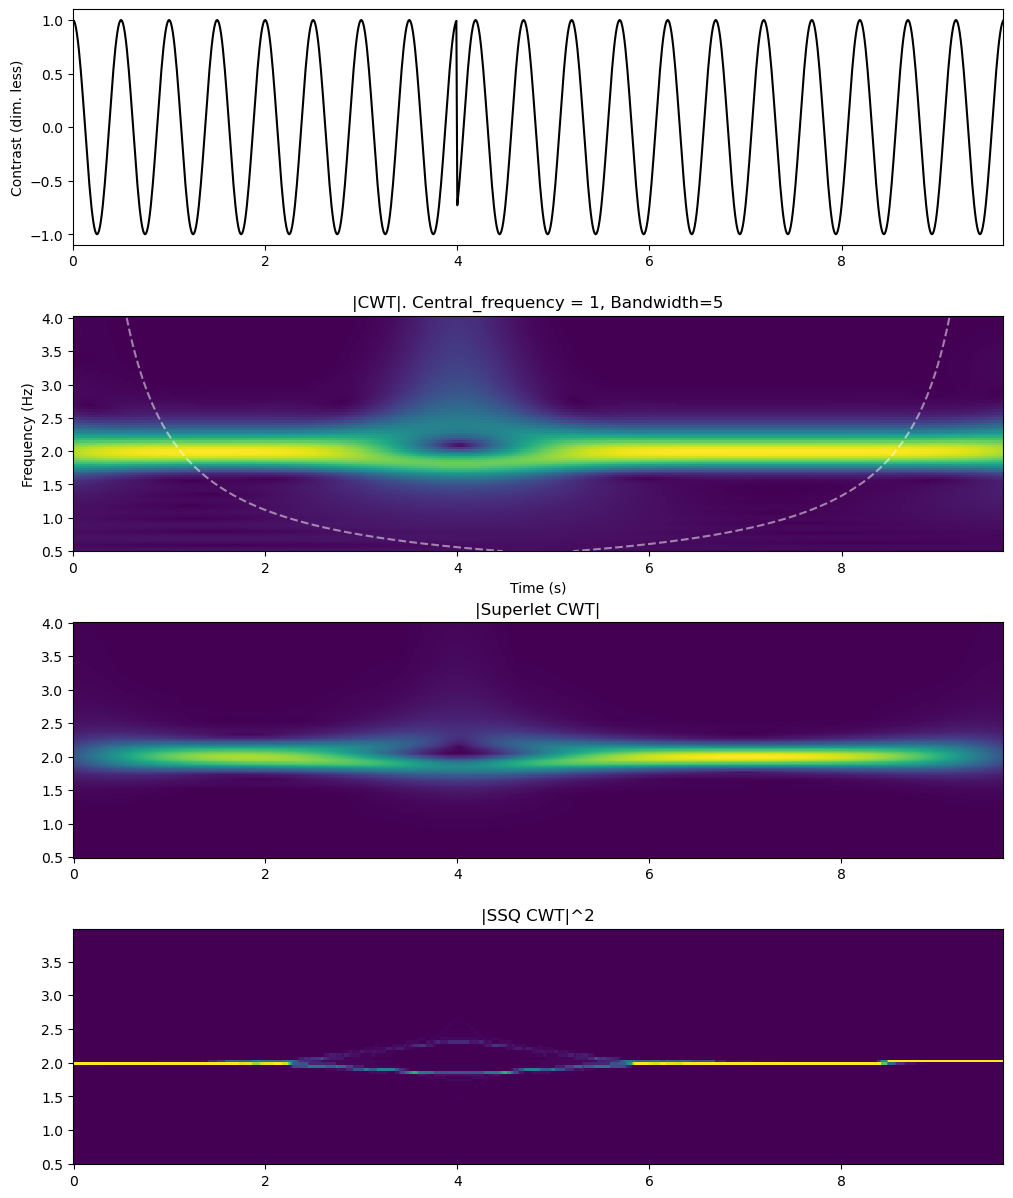

In [54]:
f, (ax,ax1,ax2,ax3) = plt.subplots(4,1,figsize=(12,15))
plt.subplots_adjust(hspace=0.3)

wf.plot_timeseries_and_its_cwt(s, t, f1=0.5, f2=4, method='fft', central_freq=1, bandwidth=5, show_smoothed=False, axs=(ax,ax1))
ax1.set_title('|CWT|. Central_frequency = 1, Bandwidth=5')

wf.plot_cwt(suplet.coefs, suplet.frequencies, t, ax=ax2)
ax2.set_title('|Superlet CWT|')

wf.plot_cwt(abs(Tx)**2, ssq_freqs, t, ax=ax3, vmax=0.012)
ax3.set_title('|SSQ CWT|^2')

# Same, with noise

In [55]:
fs = 100
t,s = sg.cosine(10, 2, fs)
s += np.random.randn(s.size)*2

## Phase shift at t=4 s
t_shift = 4
ndrop = 30
s_ = s[t>t_shift][ndrop:]
s = np.concatenate((s[t<t_shift], s_))
t = np.arange(s.size)*np.diff(t)[0]

In [56]:
suplet = st.SuperletTransform(inputSize=s.size, 
                     samplingRate=fs, 
                     frequencyRange=(0.5,4),
                     frequencyBins=200,
                     baseCycles=5,
                     superletOrders=(1,5)
                    )

suplet.coefs = suplet.transform(s)

In [57]:
Tx, Wx, ssq_freqs, _, = ssq_cwt(s, wavelet='morlet', fs=fs, padtype='symmetric')

Wx = Wx[(ssq_freqs>0.5)&(ssq_freqs<4), :]
Tx = Tx[(ssq_freqs>0.5)&(ssq_freqs<4), :]
ssq_freqs = ssq_freqs[(ssq_freqs>0.5)&(ssq_freqs<4)]

Text(0.5, 1.0, '|SSQ CWT|^2')

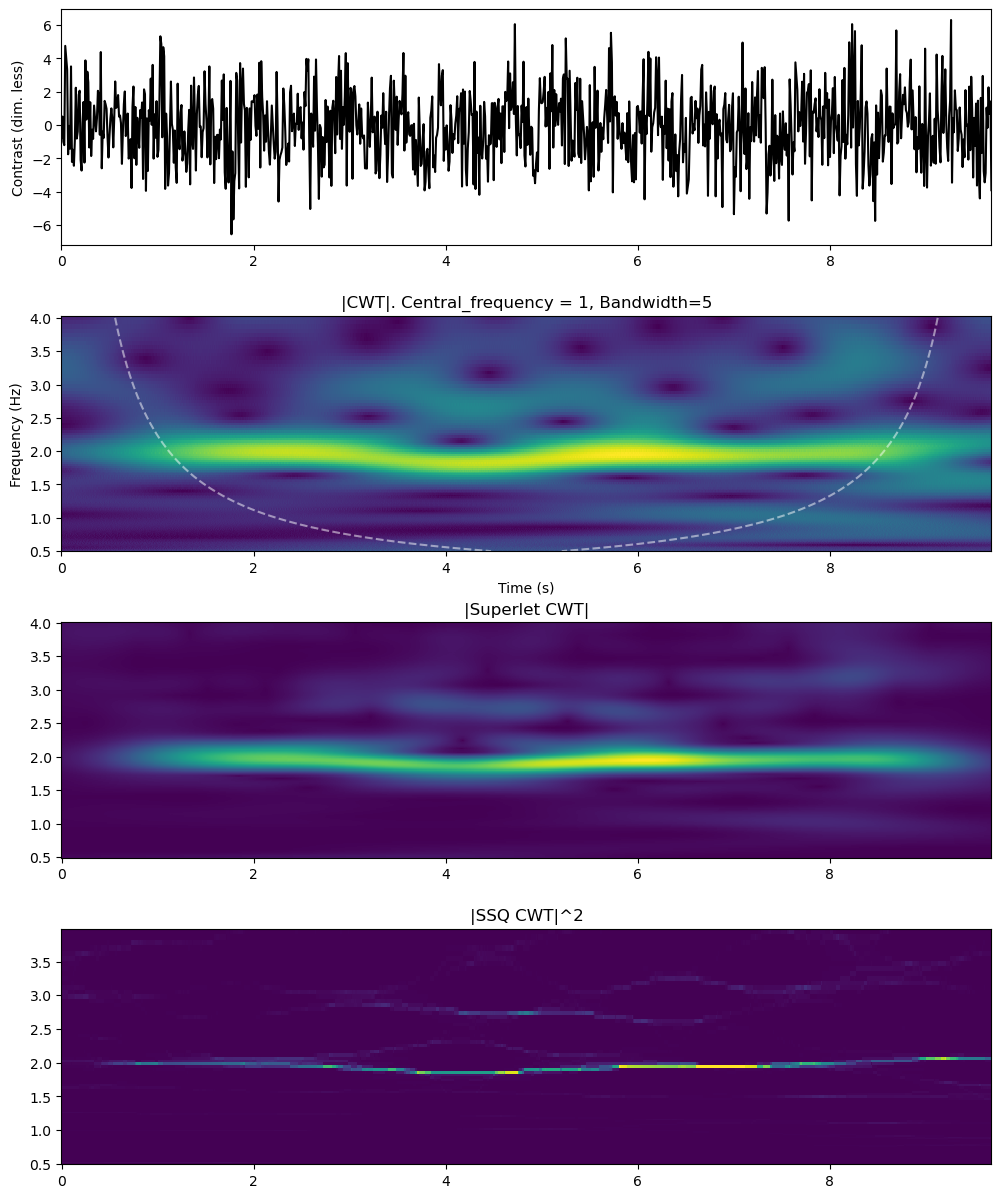

In [58]:
f, (ax,ax1,ax2,ax3) = plt.subplots(4,1,figsize=(12,15))
plt.subplots_adjust(hspace=0.3)

wf.plot_timeseries_and_its_cwt(s, t, f1=0.5, f2=4, method='fft', central_freq=1, bandwidth=5, show_smoothed=False, axs=(ax,ax1))
ax1.set_title('|CWT|. Central_frequency = 1, Bandwidth=5')

wf.plot_cwt(suplet.coefs, suplet.frequencies, t, ax=ax2)
ax2.set_title('|Superlet CWT|')

wf.plot_cwt(abs(Tx)**2, ssq_freqs, t, ax=ax3, vmax=0.012)
ax3.set_title('|SSQ CWT|^2')